# Actividad 1. Análisis y tratamiento de Dataset de Perfiles hepáticos

**Nota:** La descripción de cada variable (columnas) ha sido generada con ayuda de IA. También he dejado anotaciones de más en el código para el posterior estudio de la asignatura.

### Carga de Datos del CSV + librerías

In [1]:
# Librerías
import pandas as pd
import matplotlib.pyplot as plt  #pyplot es un módulo de matplotlib, parecido a MATLAB. Permite graficar
import seaborn as sns # Para el gráfico de correlación

# Directorio del CSV
import os  #Paquete para que Python interacte directamente con el SO. Bueno para navegar por rutas y trabajar en CSV. 
os.chdir("C:\\Users\\npale\\Documents\\UNIR\\Tratamiento de Datos\\act1") #Directorio donde se encuentra el CSV

#Carga de datos del archivo CSV
datos = pd.read_csv("liver_disease.csv")

print(datos)

     Age  Gender    TB   DB  Alkphos  Sgpt  Sgot   TP  ALB  A/G Ratio  \
0     65  Female   0.7  0.1      187    16    18  6.8  3.3       0.90   
1     62    Male  10.9  5.5      699    64   100  7.5  3.2       0.74   
2     62    Male   7.3  4.1      490    60    68  7.0  3.3       0.89   
3     58    Male   1.0  0.4      182    14    20  6.8  3.4       1.00   
4     72    Male   3.9  2.0      195    27    59  7.3  2.4       0.40   
..   ...     ...   ...  ...      ...   ...   ...  ...  ...        ...   
578   60    Male   0.5  0.1      500    20    34  5.9  1.6       0.37   
579   40    Male   0.6  0.1       98    35    31  6.0  3.2       1.10   
580   52    Male   0.8  0.2      245    48    49  6.4  3.2       1.00   
581   31    Male   1.3  0.5      184    29    32  6.8  3.4       1.00   
582   38    Male   1.0  0.3      216    21    24  7.3  4.4       1.50   

     Selector  
0           1  
1           1  
2           1  
3           1  
4           1  
..        ...  
578        

# Datos. Perfiles Hepáticos

**El dataset que hemos importado, consta de 11 columnas. Cada una de ellas, con variables de perfiles hepáticos.**

#### Variables de Bilirrubina (Deshechos)

**- TB (Bilirrubina Total):** Pigmento amarillo que se forma cuando los glóbulos rojos viejos de descomponen. El hígado es el encargado de filtrarlo.<br>
**- DB (Bilirrubina Directa):** Parte de la bilirrubina que el hígado ya ha procesado y "empaquetado" para ser expulsada. Los valores altos
                                correlación negativa con Selector), suelen indicar que el hígado no lo está filtrando bien o obstrucción.

#### Enzimas Hepáticas (Alertas de daño)

**- Alkphos (Fosfatala Alcalina):** Encima relacionada con los conductos biliares y huesos.<br>
**- SGT (ALT):** Encima más específica. Al morir las células del hígado o ser dañadas, la SGPT se filtra hacia la sangre.<br>
**- SGOT (AST):** Similar a la SGT, pero tiene presencia también en corazón y músculos. Si son muy elevadas, el paciente suele estar
                en el Selector 1 (Enfermo).

#### Proteínas (Capacidad de fabricación)

**- TP (Proteínas Totales):** Mide la cantidad total de albúmina y globulina en sangre.<br>
**- ALB (Albúmina):** Proteína más importante que produce el hígado. La relación se invierte. Un hígado sano fabrica mucha Albúmina. Valores altos
                        de albúmina se asocian al grupo 2 (Sano), da una correlación positiva.

#### Índices y ratios

**- A/G Ratio (Albumina/Ratio de Globulina):** División entre la Albúmina y restro de proteínas (Globulinas). Un ratio bajo, suele significar inflamación o enfermedad crónica.<br>
**- Age (Edad):** Indica si la enfermedad es más común en jóvenes o adultos.<br>
**- Gender (Género):** Permite ver si hay una predisposición mayor en hombres o mujeres (en este dataset hay más hombres).<br>
**- Selector (Enfermo):** Indica si hay presencia de enfermedad Hepática o no. 1 = Positivo, 2 = Negativo.




## 1. Medidas de dispersión de las variables TB y DB

In [2]:
# 1. Media
media_TB = datos['TB'].mean()
media_DB = datos['DB'].mean()

# 2. Desviación Estándar
std_TB = datos['TB'].std()
std_DB = datos['DB'].std()

# 3. Varianza
var_TB = datos['TB'].var()
var_DB = datos['DB'].var()

# 4. Rango (Máximo - Mínimo)
rango_TB = datos['TB'].max() - datos['TB'].min()
rango_DB = datos['DB'].max() - datos['DB'].min()

# 5. Rango Intercuartílico 
# IQR = Q3 (75%) - Q1 (25%)
iqr_TB = datos['TB'].quantile(0.75) - datos['TB'].quantile(0.25)
iqr_DB = datos['DB'].quantile(0.75) - datos['DB'].quantile(0.25)


#Resultados
print("Resultados para TB (Bilirrubina Total):")
print("- Media:", media_TB, 
      "\n" "- Desviación Estándar:", std_TB, 
      "\n" "- Varianza:", var_TB,
      "\n" "- Rango:", rango_TB,
      "\n" "- Rango Intercuartílico:", iqr_TB)

print("\n""Resultados para DB (Bilirrubina Directa):")
print("- Media:", media_DB, 
      "\n" "- Desviación Estándar:", std_DB, 
      "\n" "- Varianza:", var_DB,
      "\n" "- Rango:", rango_DB,
      "\n" "- Rango Intercuartílico:", iqr_DB)

Resultados para TB (Bilirrubina Total):
- Media: 3.298799313893653 
- Desviación Estándar: 6.209521726180145 
- Varianza: 38.558160067903245 
- Rango: 74.6 
- Rango Intercuartílico: 1.8

Resultados para DB (Bilirrubina Directa):
- Media: 1.486106346483705 
- Desviación Estándar: 2.8084976176589636 
- Varianza: 7.887658868396073 
- Rango: 19.599999999999998 
- Rango Intercuartílico: 1.1


### Parte 1. Interpretación de los resultados en las variables TB y DB

**- Media:** La media en la TB es el doble de alta que en la DB. Esto se debe a que la Bilirruina Total (TB) incluye la Directa y la Indirecta.<br>
**- Desviación Estándar:** En ambas variables, vemos una Desviación Estándar de casi el doble comparado a las medias. Esto es debido a que los datos están muy disperor (hay pacientes con niveles sanos y otros con niveles muy elevados).<br>
**- Varianza:** En este caso, pasa muy parecido a como se ha comportado la Desviación Estándar. Tenemos un grupo de pacientes muy heterogéneos. Lo tomamos como paso intermedio para la Desviación Estándar.<br>
**- Rango:** El Rango es sumamente sensible a los outliers, por lo que, al tener una muestra de pacientes muy heterogénea, tampoco le he dado mayor importancia.<br>
**- Rango intercuartílico:** En el rango intercuartílico, ya nos encontramos los datos más limpios, ignorando así a los pacientes "extremos". En ambas variables, el IQR es muy pequeño comparado con su Rango, por lo que en este dataset nos estamos encontrando que los valores muy altos son casos aislados (pocos). Además, al tener un IQR estrecho, nos demuestra que hay un 'estándar' en el grupo. Lo más probable es que la mayoría de pacientes presenten valores de TB y DB normales.

## 2. Caracterización de las distribuciones TB, DB, Alkphos, Sgpt

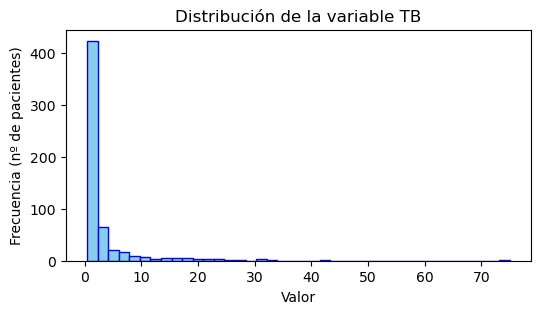

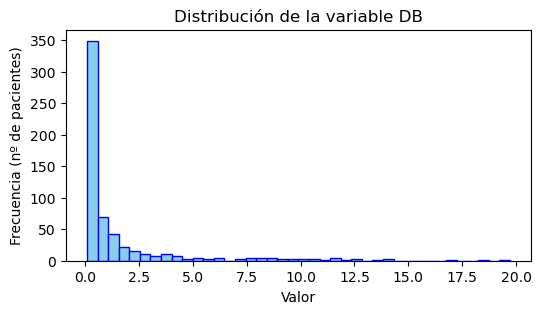

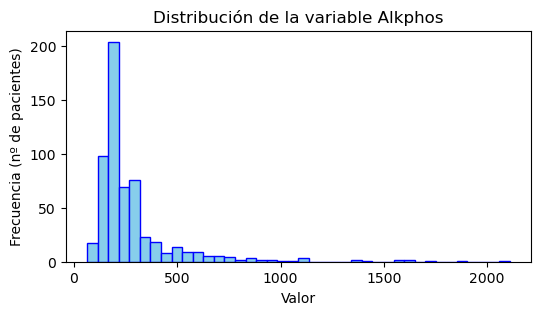

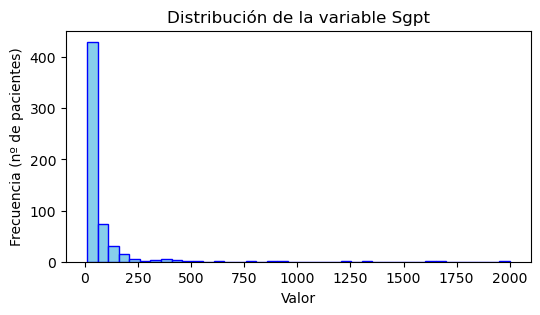

In [3]:
# Variables que queremos analizar
variables = ['TB', 'DB', 'Alkphos', 'Sgpt']

for var in variables: 
    plt.figure(figsize=(6, 3)) # Tamaño de la imagen
    
    # Creamos el histograma
    # 'bins' es el número de barras; 'edgecolor' el contorno de las barras; .dropna() elimina los valores nulos
    plt.hist(datos[var].dropna(), bins=40, color='skyblue', edgecolor='blue') 
    
    # Títulos y etiquetas
    plt.title(f'Distribución de la variable {var}')
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia (nº de pacientes)')
    
    plt.show() # Muestra el gráfico

### Parte 2. Interpretación de las distribuciones TB, DB, Alkphos, Sgpt

**- Asimetría positiva:** Las cuatro variables presentan una asimetría positiva, a parte de tener una distribución lepotocúrtica (picos muy altos y estrechos). En los cuatro casos, nos está indicando que la mayoría de pacientes tiene niveles bajos (normales). Pero, como ya habíamos intuído en el anterior ejercicio, hay un pequeño grupo de pacientes con valores extremadamente altos debido a su enfermedad.


## 3. Valores atípicos Sgot, TP, ALB, A/G Ratio

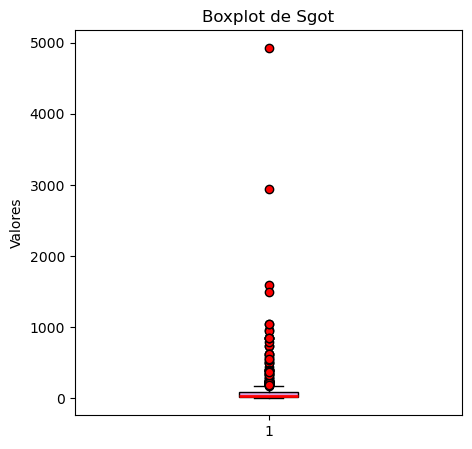

VARIABLE: Sgot
  - Cantidad de atípicos: 66
----------------------------------------


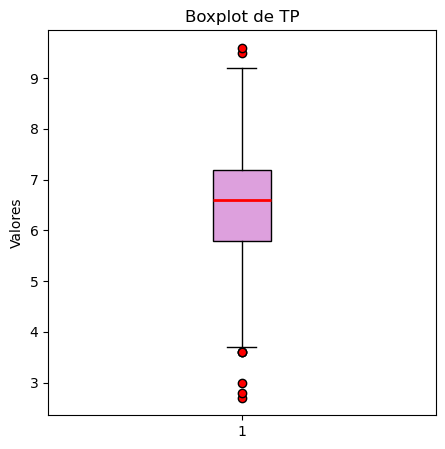

VARIABLE: TP
  - Cantidad de atípicos: 8
----------------------------------------


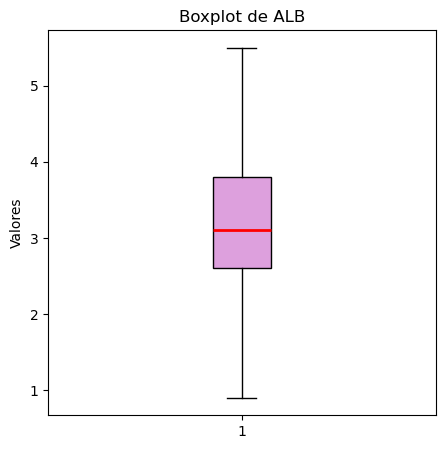

VARIABLE: ALB
  - Cantidad de atípicos: 0
----------------------------------------


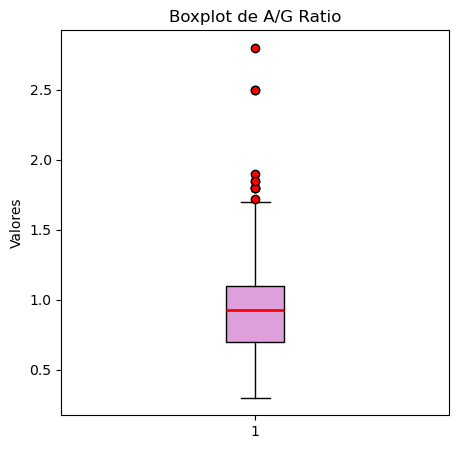

VARIABLE: A/G Ratio
  - Cantidad de atípicos: 10
----------------------------------------


In [4]:
# Variables a analizar
variables = ['Sgot', 'TP', 'ALB', 'A/G Ratio']

for var in variables:

    #Limpieza de valores nulos. Evita errores al procesar los datos
    col = datos[var].dropna()
    
    # 2. Cálculo manual de la Regla de Tukey (Límites)
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    ls = q3 + 1.5 * iqr
    li = q1 - 1.5 * iqr
    
    # 3. Identificación de atípicos
    atipicos = col[(col < li) | (col > ls)]
    num_atipicos = len(atipicos)
    
    # 4. Gráfico de caja pintado
    plt.figure(figsize=(5, 5))
    plt.boxplot(col, patch_artist=True, 
                boxprops=dict(facecolor='plum', color='black'), # Color lila para variar
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(markerfacecolor='red', marker='o'))
    
    plt.title(f'Boxplot de {var}')
    plt.ylabel('Valores')
    plt.show()
    
    # 5. Salida de texto para tu descripción
    print(f"VARIABLE: {var}")
    print(f"  - Cantidad de atípicos: {num_atipicos}")
    print("-" * 40)
   

### Parte 3. Interpretación de los Boxplot y valores atipicos para Sgot, TP, ALB, A/G Ratio

#### Sgot (AST)

**- Cantidad de valores atípicos:** Se han identificado 66 valores atípicos. Es una cifra algo alta (más del 10% de la muestra). Nos entá indicando que esta variable es sumamente inestable en pacientes con problemas de hígado.<br>
**- Interpretación:** La caja está prácticamente aplastada hacia el cero. Esto nos indica que la mayoría de pacientes tienen valores normales y bajos. El Sgot es una enzima que se libera al haber necrosis de las células hepáticas, lo que los outliers no están indicando que hay varios pacientes con follo hepático agudo y/o daños graves.

#### TP (Proteínas Totales)

**- Cantidad de valores atípicos:** Se han identificado 8 valores atípicos. Es una cantidad muy pequeña en comparación con el Sgot. Nos está indicando que los niveles de proteína en sangre no flucúan de forma tan errática como las enzimas.<br>
**- Interpretación:** La caja está bien formada y la mediana está casi en el centro. Esto nos indica que tiene una distribución normal (en forma de campana de Gauss). Además, aquí nos encontramos los outliers por la parte superior e inferior de la caja, lo que nos indica que; los valores superiores corresponden a pacientes con deshidratación severa o inflamaciones crónicas; los valores inferiores son los más preocupantes clínicamente hablando, ya que indican hipoproteinemia grave (signo de daño crónico avanzado).

#### ALB (Albúmina)

**- Cantidad de valores atípicos:** Nos encontramos con 0 valores atípicos, por lo que nos indica que es la variable más limpia y estable de todo el conjunto. Es estadísticamente muy significativo.<br>
**- Interpretación:** La caja es amplia y proporcional, estos valores son indicativo de que la albúmina se distribuye de manera uniforme en los pacientes. También tenemos la mediana en el centro de la caja, lo que sugiere una distribución que se acerca aún más a la campana de Gauss. Aquí la población está siguiendo un patrón predecible y carecen de picos extremos. Comparándolo con las demás variables, esto es indicativo de que aunque el hígado esté dañado, los niveles de la Albúmina no cambian de forma tan errática como los demás.

#### A/G Ratio

**- Cantidad de valores atípicos:** Aquí se han identificado 10 valores atípicos. Es una cantidad moderada entre los 0 de la Albúmina y los 66 de la Sgot.<br>
**- Interpretación:** La caja se sitúa en la parte inferior del gráfico, por lo que tiene una asimetría positiva. La mitad central de los pacientes (caja) nos muestra que en condiciones normales, el equilibrio entre proteínas es muy constante. En esta variable, los outliers suelen ser menos comunes en enfermedades hepáticas graves, lo que pueden también ser indicador de niveles muy bajos de globulinas. 



## 4. Matriz de correlación

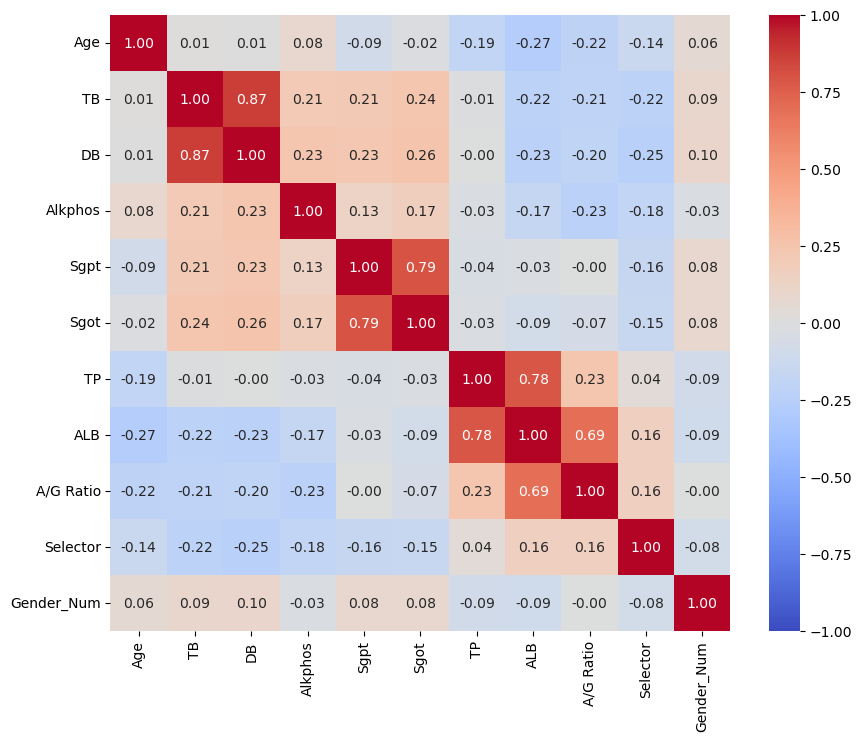

In [5]:
# Matriz de correlación

# Selección tipo de datos + transformación
datos['Gender_Num'] = datos['Gender'].map({'Male': 1, 'Female': 0}) #Creamos una nueva columna 'Gender_Num' con las variables de Sexo convertidas en booleanos/numéricas
datos_numericos = datos.select_dtypes(include=['number']) #Eliminamos posibles errores, nos quedamos sólo con los datos numéricos
mat_corr = datos_numericos.corr() # Creamos la matriz de correlación

# Gráfico con Seaborn (más visual)
plt.figure(figsize=(10, 8))
sns.heatmap(mat_corr, annot=True, cmap="coolwarm", # annot: Añade los números dentro cada cuadrado, cmap: Paleta de colores, 
            fmt=".2f",    # fmt: cuantos decimales mostrar
            vmin=-1,      # En nuestro caso Python lo puso automáticamente a -0,2. Lo forzamos a -1
            vmax=1,       
            center=0) 

plt.show()

### Parte 4. Interpretación de la matriz de correlación

#### Correlaciones Positivas

**- TB y DB (0,87):** Aquí tenemos la relación más fuerte. Como vimos en el primer ejercicio, la bilirrubina directa es parte de la total.<br> 
**- Sgpt y Sgot (0,79):** También muestran una relación positiva fuerta con el daño hepático. Que el valor sea menor que 1, sugiere que hay patologías donde una sube más que la otra. También vimos en el ejercicio 2 la relación que ambas variables muestran en las medidas de dispersión.<br> 
**- TP y ALB (0,78):** Confirma que la albúmina el es componente proteico que más varía y domina el total de las proteinas en la población.<br> 
**- ALB y A/G Ratio (0,69):** Tiene una correlación moderada, tirando a alta. Esto se debe a que la albúmina es el numerados de esa división. 

#### Correlaciones negativas

**- Selector y DB (-0,25), TB (-0,22):** Al ser 1 el enfermo y sano el 2, la correlación negativa moderada que muestran las variables, nos indica que a mayor nivel de bilirrubina, menor es el número del Selector. Es de decir, que los valores altos de bilirrubina, empujan hacia el diagnóstico de enfermo (1).<br> 
**- Age y Albúmina (-0,27):** A medida que aumenta la edad del paciente, los niveles de albúmina tienden a la baja.<br> 
**- Age y TP (-0,19):** Pasa lo mismo que con la albúmina, la edad está relacionada con los niveles que bajan.<br> 

#### Correlaciones con el Selector

**- Bilirrubinas:** **Comentado en las correlaciones negativas<br> 
**- ALB (0,16) y A/G Ratio (0,16):** Correlación positiva. Un mayor nivel de proteína, suele ser manifiesto de pacientes sanos (2).<br> 
**- Age (-0,14)** Como se ha comentado anteriormente, hay una ligera tendencia que a mayor edad, mayor probabilidad de enfermedad. Pero cabe recalcar que esta relación es débil.

#### Independencia de variables

**- Gender:** Tiene correlaciones sumamente bajas, rozando al 0. Esto indica que los niveles de enzimas o bilirrubina no dependen del sexo del paciente.<br> 
**- Alkphos y ALB (-0,17):** Relación casi inexistente. Significa que la obstrucción de bilis (Alkphos) y la capacidad de síntesis (ALB), son procesos que pueden fallar de forma independiente.
